In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [123]:
d = np.load('u_allt_backward.npy', 'r') #_backward

In [124]:
d.shape

(1000, 1, 1, 298, 554)

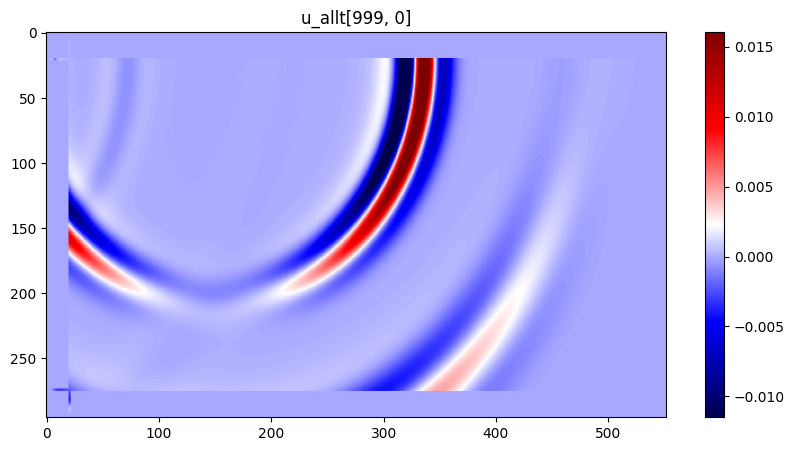

In [127]:
t = 999

abcn = 0
M = 1
b = abcn + M

plt.figure(figsize=(10, 5))
vmin, vmax = np.percentile(d[t].squeeze()[b:-b,b:-b], [0.5, 99.5])
plt.imshow(d[t].squeeze()[b:-b,b:-b], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar()
plt.title(f'u_allt[{t}, 0]')
plt.show()

In [34]:
models = ['Vp', 'Vs', 'Density']
model_no = 1
vp_ad = np.load(f'{models[model_no]}_grad_ad.npy')
vp_cuda = np.load(f'{models[model_no]}_grad_cuda.npy')
assert vp_ad.shape == vp_cuda.shape

FileNotFoundError: [Errno 2] No such file or directory: 'Vs_grad_ad.npy'

NameError: name 'vp_ad' is not defined

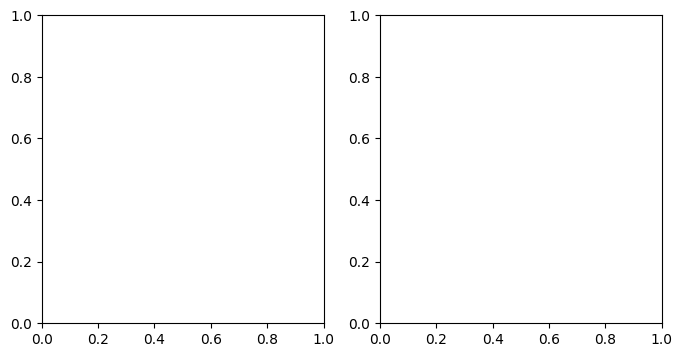

In [35]:
# vp_ad/= np.max(np.abs(vp_ad))
# vp_cuda/= np.max(np.abs(vp_cuda))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
vmin, vmax = np.percentile(vp_ad, [2, 98])
axes[0].imshow(vp_ad, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('AD')
vmin, vmax = np.percentile(vp_cuda, [2, 98])
axes[1].imshow(vp_cuda, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('CUDA')
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(figsize=(8, 4))
trace_no = 10#vp_ad.shape[1]//2
t_ad = vp_ad[:, trace_no].copy()
t_ad/=np.abs(t_ad).max()
t_cuda = vp_cuda[:, trace_no].copy()
t_cuda/=np.abs(t_cuda).max()
plt.plot(t_ad, label='AD')
plt.plot(t_cuda, label='CUDA')
plt.legend()
plt.show()

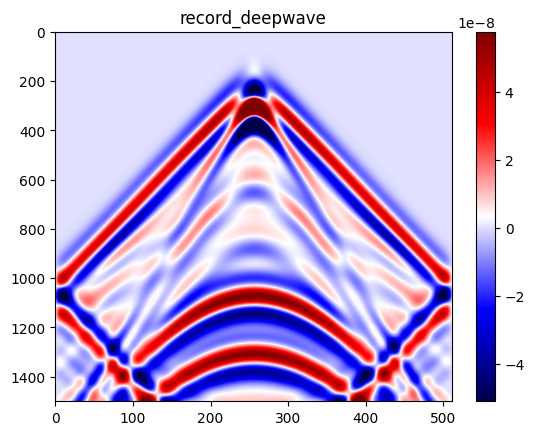

In [76]:
dw_record = np.load('record_deepwave.npy')
vmin, vmax = np.percentile(dw_record, [0.5, 99.5])
plt.imshow(dw_record.squeeze().T, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar()
plt.title(f'record_deepwave')
plt.show()

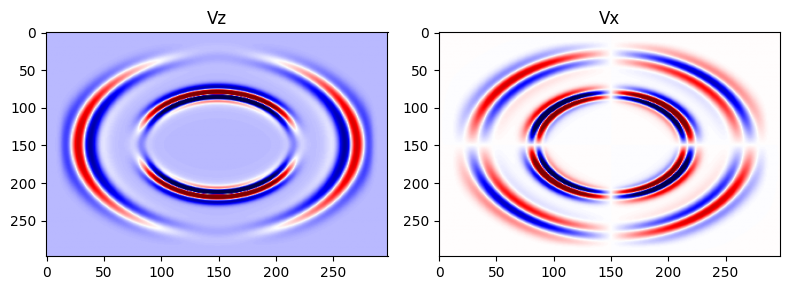

In [81]:
u_last_sweep = np.load('/ibex/user/wangs0j/geophyai/test/cuda/u_last.npy')
vx, vz = u_last_sweep[:2]

fig, axes = plt.subplots(1, 2, figsize=(8,3))
vmin, vmax = np.percentile(vz, [0.5, 99.5])
im = axes[0].imshow(vz[0].squeeze().T, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('Vz')
vmin, vmax = np.percentile(vx, [0.5, 99.5])
im = axes[1].imshow(vx[0].squeeze().T, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('Vx')
plt.tight_layout()
plt.savefig('wavefield_sweep.png', dpi=300)
plt.show()

In [44]:
rec_cuda = np.load('record_CUDA.npy').squeeze().T
rec_torch = np.load('record_PyTorch.npy').squeeze()
print(np.allclose(rec_cuda, rec_torch, atol=1e-5))
print(rec_cuda.shape, rec_torch.shape)

True
(1000, 512) (1000, 512)


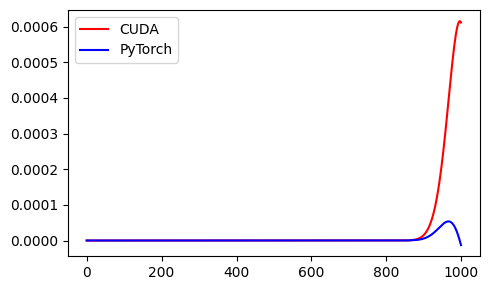

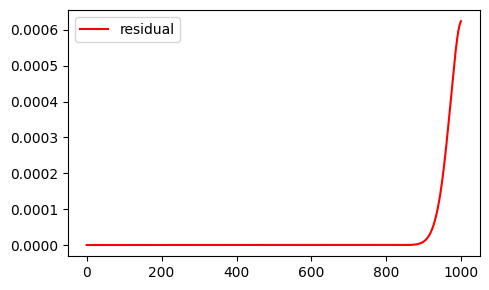

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(rec_cuda, 'r', label='CUDA')
ax.plot(rec_torch, 'b', label='PyTorch')
ax.legend()
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(rec_cuda-rec_torch, 'r', label='residual')
ax.legend()
plt.tight_layout()
plt.show()


NameError: name 'rec_torch' is not defined

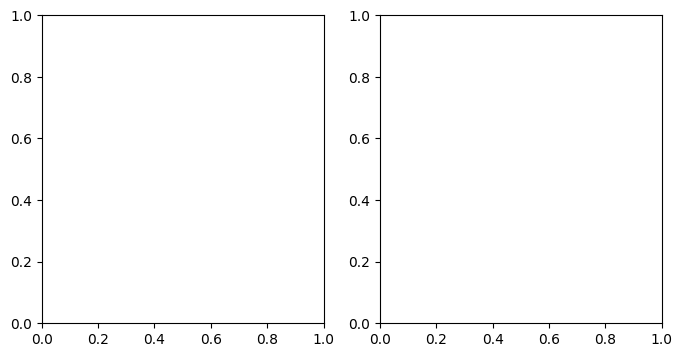

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
vmin, vmax = np.percentile(rec_torch, [0.5, 99.5])
axes[0].imshow(rec_cuda, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title('CUDA')
axes[1].imshow(rec_torch, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title('PyTorch')
plt.tight_layout()
plt.show()

# Check boundary

0.9260123
22


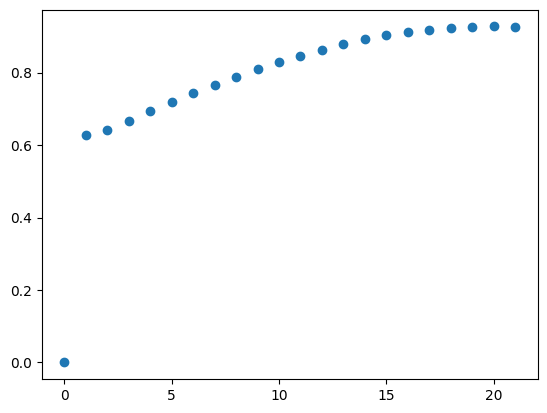

In [90]:
pml = np.load('azh.npy').squeeze()
end_point = 22
print(pml[:end_point][-1])
print(len(pml[:end_point]))
plt.scatter(np.arange(end_point), pml[:end_point])
plt.show()

# Check adjoint pytorch

In [17]:
adj_pytorch = np.load('/ibex/user/wangs0j/geophyai/test/cuda/adjoint_wavefields_torch.npy', 'r')
adj_cuda = np.load('/data/tmp/u_allt_backward.npy', 'r')
print(adj_pytorch.shape, adj_cuda.shape)

(1000, 5, 1, 1, 296, 552) (5, 1000, 1, 1, 308, 564)


In [24]:
308-296

12

In [18]:
vx, vz, sxx, szz, sxz = adj_pytorch[:,0], adj_pytorch[:,1], adj_pytorch[:,2], adj_pytorch[:,3], adj_pytorch[:,4]
vx_cuda, vz_cuda, sxx_cuda, szz_cuda, sxz_cuda = adj_cuda[0], adj_cuda[1], adj_cuda[2], adj_cuda[3], adj_cuda[4]

In [19]:
vx_cuda.shape

(1000, 1, 1, 308, 564)

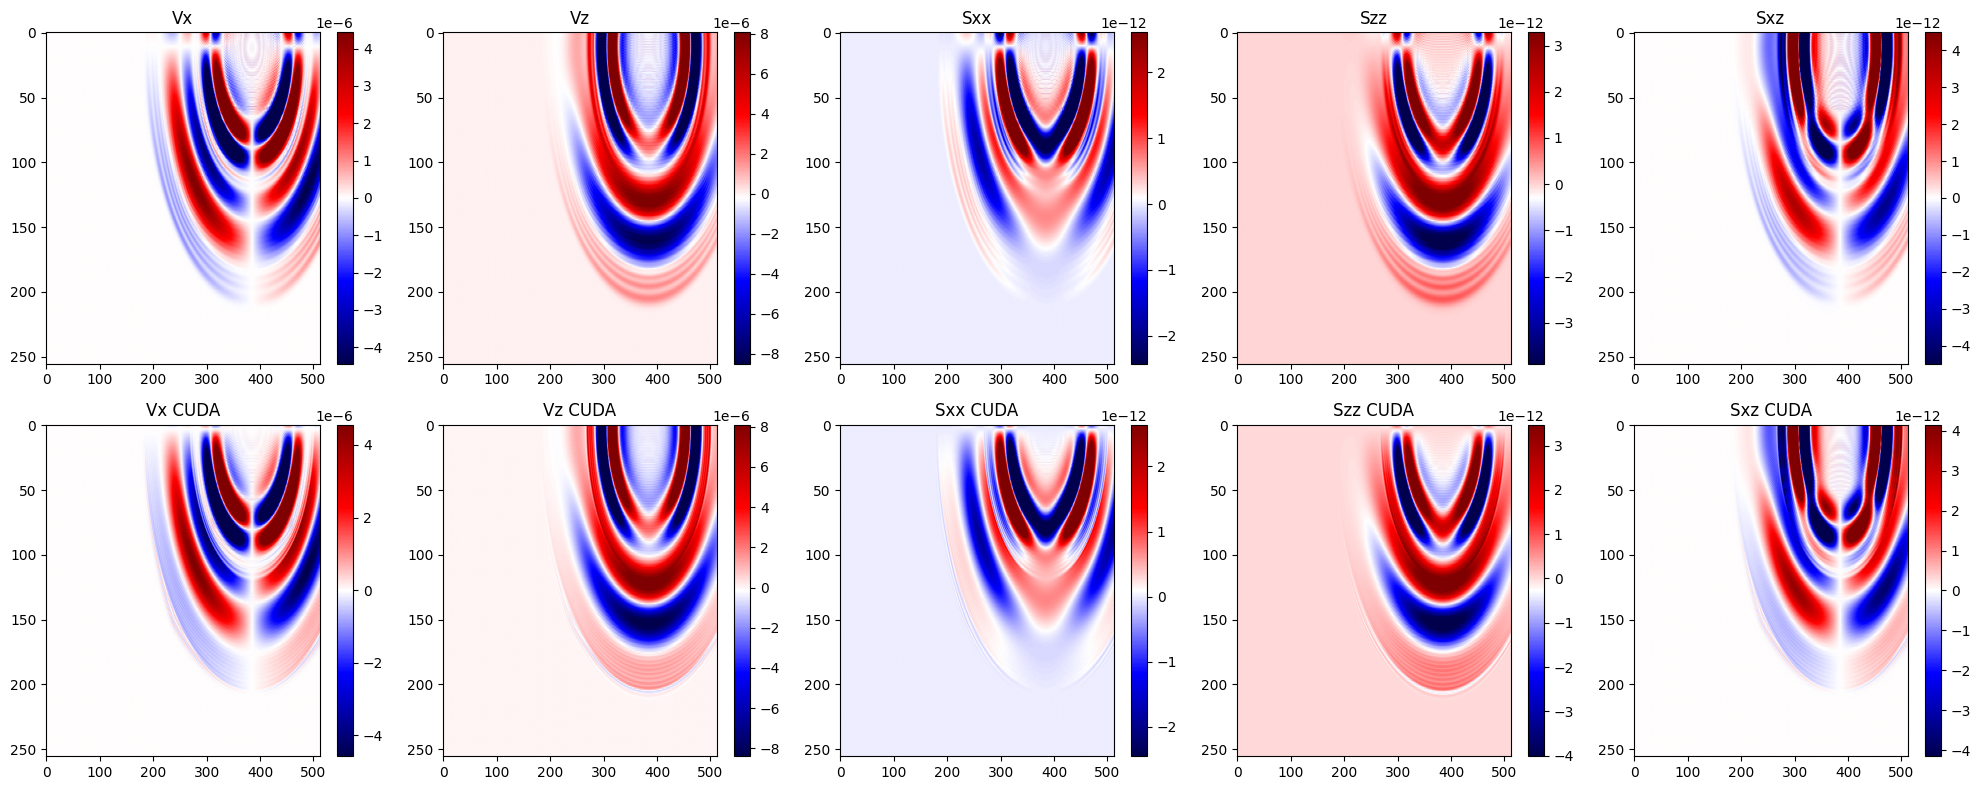

In [25]:
show_t = 500
b = 20
bcuda = 26
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, (field, field_cuda, name) in enumerate(zip([vx, vz, sxx, szz, sxz], [vx_cuda, vz_cuda, sxx_cuda, szz_cuda, sxz_cuda], ['Vx', 'Vz', 'Sxx', 'Szz', 'Sxz'])):
    vmin, vmax = np.percentile(field[show_t].squeeze()[b:-b,b:-b], [2, 98])
    ax = axes[0,i].imshow(field[show_t].squeeze()[b:-b,b:-b], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(ax, ax=axes[0,i])
    axes[0,i].set_title(name)

    scale = -1 if 'S' in name else 1
    vmin, vmax = np.percentile(scale*field_cuda[show_t].squeeze()[bcuda:-bcuda,bcuda:-bcuda], [2, 98])
    ax = axes[1,i].imshow(scale*field_cuda[show_t].squeeze()[bcuda:-bcuda,bcuda:-bcuda], cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(ax, ax=axes[1,i])
    axes[1,i].set_title(name + ' CUDA')

plt.tight_layout()
plt.show()

# Check adjoint and forward data

In [29]:
u_adjoint = np.load('/data/tmp/u_adoint.npy', 'r')
u_forward = np.load('/data/tmp/u_forward.npy', 'r')

In [30]:
print(u_adjoint.shape, u_forward.shape)

(5, 1000, 1, 1, 312, 568) (1000, 1, 1, 312, 568)


In [31]:
vz_adjoint = u_adjoint[1].squeeze()
vz_forward = u_forward.squeeze()

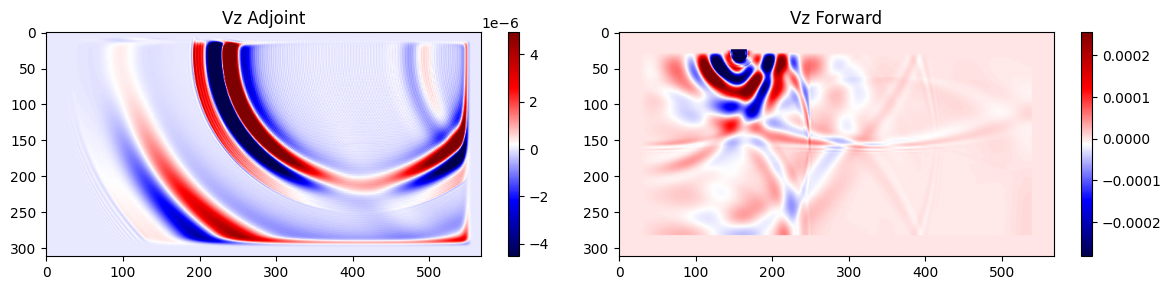

In [43]:
show_t = 50
show_vz_adjoint = vz_adjoint[show_t]
show_vz_forward = vz_forward[show_t]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
vmin, vmax = np.percentile(show_vz_adjoint, [2, 98])
ax = axes[0].imshow(show_vz_adjoint, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar(ax, ax=axes[0])
axes[0].set_title('Vz Adjoint')

vmin, vmax = np.percentile(show_vz_forward, [0.5, 99.5])
ax = axes[1].imshow(show_vz_forward, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar(ax, ax=axes[1])
axes[1].set_title('Vz Forward')

plt.tight_layout()
plt.show()